# Control-Effectiveness Experiment: Baseline / Target / Measured / Error

This notebook runs the **measurable experiment** called for in the PRD: it uses the same scoring/attribution engine that powers the API (`backend/app/scoring.py`) directly against the seeded dataset, and reports:

- **Baseline** business risk (180 days before today, before this remediation period)
- **Target** business risk (if the current control plan finishes, capped at a 90% max-effectiveness ceiling — no program eliminates residual risk entirely)
- **Measured** business risk (today, confidence-weighted by evidence quality)
- **Error analysis**: a confidence band on the measured value and the attributed reduction, driven by how much of the completed-control evidence is actually verified vs. self-attested vs. stale/missing
- A **sensitivity analysis**: what happens to the headline reduction number if we assume evidence trust is worse than it looks

Run top-to-bottom against the dataset produced by `data-gen/generate_data.py`.

In [1]:
import sys, os
sys.path.insert(0, os.path.join(os.getcwd(), '..', 'backend'))

from datetime import date, timedelta
import pandas as pd
import matplotlib.pyplot as plt

from app.database import SessionLocal
from app import models, scoring

db = SessionLocal()
TODAY = date.today()
BASELINE_DATE = TODAY - timedelta(days=180)
ORGS = [o.id for o in db.query(models.Organization).filter(models.Organization.org_type == 'plant').all()]
ORGS

['chennai', 'coimbatore', 'bengaluru', 'hyderabad', 'pune', 'mumbai']

## 1. Baseline / Target / Measured, per organization

In [2]:
rows = []
attributions = {}
for org_id in ORGS:
    org = db.query(models.Organization).filter(models.Organization.id == org_id).first()
    attribution = scoring.compute_attribution(db, org_id, BASELINE_DATE, TODAY)
    attributions[org_id] = attribution
    rows.append({
        'org': org.name,
        'baseline': round(attribution.baseline.normalized_score, 2),
        'target': round(attribution.target.normalized_score, 2),
        'measured_point': round(attribution.measured_point.normalized_score, 2),
        'measured_low_bound': round(attribution.measured_high.normalized_score, 2),   # best case -> lowest risk
        'measured_high_bound': round(attribution.measured_low.normalized_score, 2),   # worst case -> highest risk
        'reduction_pct': attribution.reduction_pct,
        'reduction_range_pct': (
            round(attribution.reduction_low / attribution.baseline.raw_score * 100, 1),
            round(attribution.reduction_high / attribution.baseline.raw_score * 100, 1),
        ),
        'pct_of_target_achieved': attribution.pct_of_target_achieved,
        'residual_interaction_effect': attribution.residual,
    })

df = pd.DataFrame(rows)
df

,org,baseline,target,measured_point,measured_low_bound,measured_high_bound,reduction_pct,reduction_range_pct,pct_of_target_achieved,residual_interaction_effect
0,Chennai Assembly Plant,8.04,0.84,6.75,6.13,7.34,16.0,"(23.7, 8.7)",17.9,39.19
1,Coimbatore Precision Works,7.91,1.35,5.45,3.02,9.11,31.2,"(61.9, -15.2)",37.6,-1646.86
2,Bengaluru Electronics Plant,4.01,0.77,3.22,2.20,5.08,19.7,"(45.0, -26.7)",24.4,-1154.74
3,Hyderabad Process Plant,10.15,1.16,9.32,7.61,10.39,8.2,"(25.0, -2.3)",9.2,-443.86
4,Pune Fabrication Plant,10.72,1.34,10.42,9.14,11.35,2.8,"(14.7, -5.9)",3.2,-738.63
5,Mumbai Packaging Plant,8.14,0.77,6.48,5.99,7.04,20.3,"(26.4, 13.5)",22.5,173.37


**Reading this table:** `reduction_pct` is the point-estimate risk reduction attributable to completed controls since baseline. `reduction_range_pct` is the error band -- how that number could look if the least-trusted evidence turns out to be wrong (low end) vs. if every piece of self-attested/stale evidence turns out to have been trustworthy after all (high end). A wide band means the headline number is resting on weak proof, not weak security -- that distinction is the whole point of tracking confidence separately from status.

## 2. Per-control attribution (marginal contribution + confidence)

In [3]:
org_id = ORGS[0]
attribution = attributions[org_id]
control_rows = [{
    'control': c.name,
    'type': c.control_type,
    'reduction_point': c.delta_point,
    'reduction_low': c.delta_low,
    'reduction_high': c.delta_high,
    'note': c.confidence_note,
} for c in attribution.per_control]
control_df = pd.DataFrame(control_rows).sort_values('reduction_point', ascending=False)
control_df

,control,type,reduction_point,reduction_low,reduction_high,note
0,Patch Management Program,patch_management,65.44,58.90,68.71,Independently verified by automated scan or au...
1,IT/OT Network Segmentation,network_segmentation,63.15,56.84,66.31,Independently verified by automated scan or au...
2,Privileged Access Control,access_control,57.08,51.38,59.94,Independently verified by automated scan or au...
3,IT/OT Network Segmentation,network_segmentation,56.02,50.41,58.82,Independently verified by automated scan or au...
4,IT/OT Network Segmentation (IT),network_segmentation,41.88,8.38,58.63,Last checked a while ago (via a third-party au...
5,Endpoint Detection & Response,edr,36.08,32.47,37.88,Independently verified by automated scan or au...
6,Patch Management Program,patch_management,32.91,16.45,39.49,"Self-attested only, not independently verified..."
7,Endpoint Detection & Response,edr,18.24,9.12,21.89,"Self-attested only, not independently verified..."
8,IT/OT Network Segmentation,network_segmentation,16.66,3.33,23.33,Last checked a while ago (via a third-party au...
9,Automated Backup & Recovery,backup,6.99,1.40,9.78,Last checked a while ago (via an automated sca...


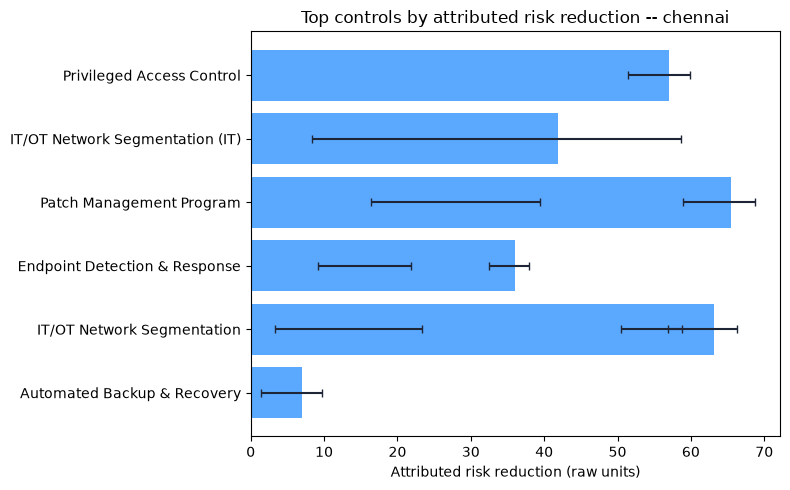

In [4]:
fig, ax = plt.subplots(figsize=(8, 5))
top = control_df.head(10).iloc[::-1]
ax.barh(top['control'], top['reduction_point'], color='#5aa9ff')
ax.errorbar(
    top['reduction_point'], top['control'],
    xerr=[top['reduction_point'] - top['reduction_low'], top['reduction_high'] - top['reduction_point']],
    fmt='none', ecolor='#1d2536', capsize=3,
)
ax.set_xlabel('Attributed risk reduction (raw units)')
ax.set_title(f'Top controls by attributed risk reduction -- {org_id}')
plt.tight_layout()
plt.savefig('control_attribution.png', dpi=120)
plt.show()

## 3. Risk trend reconstruction (baseline -> measured, vs. target)

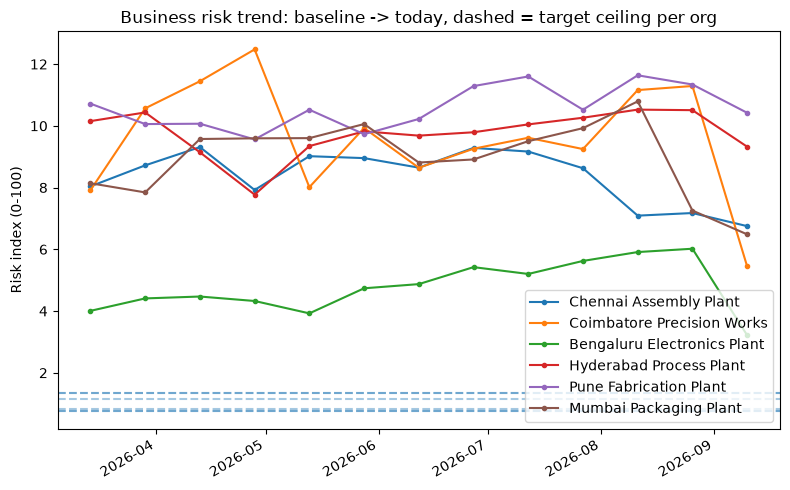

In [5]:
fig, ax = plt.subplots(figsize=(8, 5))
for org_id in ORGS:
    org = db.query(models.Organization).filter(models.Organization.id == org_id).first()
    points = []
    for m in range(180, -1, -15):
        as_of = TODAY - timedelta(days=m)
        r = scoring.business_risk(db, org_id, as_of)
        points.append((as_of, r.normalized_score))
    xs, ys = zip(*points)
    ax.plot(xs, ys, marker='o', markersize=3, label=org.name)
    target = scoring.target_business_risk(db, org_id, TODAY)
    ax.axhline(target.normalized_score, linestyle='--', alpha=0.4)

ax.set_ylabel('Risk index (0-100)')
ax.set_title('Business risk trend: baseline -> today, dashed = target ceiling per org')
ax.legend()
fig.autofmt_xdate()
plt.tight_layout()
plt.savefig('risk_trend.png', dpi=120)
plt.show()

## 4. Sensitivity analysis: what if evidence trust is worse than it looks?

This directly addresses one of the design's named weaknesses (PRD section 9: *gaming the metric* / *false attribution*). We re-run the measured score assuming every piece of `manual_attestation` evidence is actually invalid (e.g., an audit finds self-attestations were not backed by real verification), and see how much the headline reduction number moves.

In [6]:
import copy

sensitivity_rows = []
for org_id in ORGS:
    org = db.query(models.Organization).filter(models.Organization.id == org_id).first()
    attribution = attributions[org_id]

    # count how much of the point-estimate reduction depends on manual attestation only
    manual_only_controls = [c for c in db.query(models.Control).filter(
        models.Control.org_id == org_id, models.Control.status == 'completed'
    ).all()]
    manual_dependent = 0
    for c in manual_only_controls:
        ev = scoring.latest_evidence_state(db, c.id, __import__('datetime').datetime.combine(TODAY, __import__('datetime').datetime.min.time()))
        if ev.has_evidence and ev.source == 'manual_attestation':
            manual_dependent += 1

    sensitivity_rows.append({
        'org': org.name,
        'point_estimate_reduction_pct': attribution.reduction_pct,
        'worst_case_reduction_pct': round(attribution.reduction_low / attribution.baseline.raw_score * 100, 1),
        'controls_relying_on_self_attestation_only': manual_dependent,
        'total_completed_controls': len(manual_only_controls),
    })

sensitivity_df = pd.DataFrame(sensitivity_rows)
sensitivity_df

,org,point_estimate_reduction_pct,worst_case_reduction_pct,controls_relying_on_self_attestation_only,total_completed_controls
0,Chennai Assembly Plant,16.0,23.7,8,32
1,Coimbatore Precision Works,31.2,61.9,4,27
2,Bengaluru Electronics Plant,19.7,45.0,12,43
3,Hyderabad Process Plant,8.2,25.0,11,26
4,Pune Fabrication Plant,2.8,14.7,6,20
5,Mumbai Packaging Plant,20.3,26.4,4,28


## 5. Conclusion

The point-estimate headline number (`reduction_pct`) should never be quoted to a stakeholder without its companion error range -- the gap between the point estimate and the worst-case bound is a direct measure of **how much of the program's claimed success is resting on unverified self-reporting**. Closing that gap (moving self-attested controls to independently verified ones) is itself a legitimate, trackable objective for the security program, separate from completing more controls.